**INTRODUCTION**

**About This Project**

With the growing volume of digital transactions in India, particularly through UPI (Unified Payments Interface), ensuring the security of transactions and detecting fraudulent behavior has become more crucial than ever. This project aims to apply machine learning techniques to identify fraudulent UPI transactions using various transactional, demographic, and temporal features.

This is a binary classification problem, where the goal is to predict whether a given transaction is fraudulent or genuine.

**Dataset Source**

The Dataset used in this project was sourced from Kaggle and the link has been provided:

*Dataset Link:* https://www.kaggle.com/datasets/skullagos5246/upi-transactions-2024-dataset

The Dataset provides a rich set of categorical, temporal, and behavioral features, essential for training an effective fraud detection model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
%matplotlib inline
import seaborn as sn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

**READING AND PRE-PROCESSING THE DATASET**

In [2]:
upi_df = pd.read_csv('DataSets/upi_transactions_2024.csv')
print(upi_df.head(10))

  transaction id            timestamp transaction type merchant_category  \
0  TXN0000000001  2024-10-08 15:17:28              P2P     Entertainment   
1  TXN0000000002  2024-04-11 06:56:00              P2M           Grocery   
2  TXN0000000003  2024-04-02 13:27:18              P2P           Grocery   
3  TXN0000000004  2024-01-07 10:09:17              P2P              Fuel   
4  TXN0000000005  2024-01-23 19:04:23              P2P          Shopping   
5  TXN0000000006  2024-10-07 22:32:07              P2P              Food   
6  TXN0000000007  2024-02-08 10:25:57              P2P             Other   
7  TXN0000000008  2024-10-27 18:47:02              P2P         Utilities   
8  TXN0000000009  2024-11-21 09:39:16              P2P             Other   
9  TXN0000000010  2024-11-11 15:58:56              P2M           Grocery   

   amount (INR) transaction_status sender_age_group receiver_age_group  \
0           868            SUCCESS            26-35              18-25   
1          1011

Printing the Metadata of the Dataset.

In [3]:
print(upi_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype
---  ------              --------------   -----
 0   transaction id      250000 non-null  str  
 1   timestamp           250000 non-null  str  
 2   transaction type    250000 non-null  str  
 3   merchant_category   250000 non-null  str  
 4   amount (INR)        250000 non-null  int64
 5   transaction_status  250000 non-null  str  
 6   sender_age_group    250000 non-null  str  
 7   receiver_age_group  250000 non-null  str  
 8   sender_state        250000 non-null  str  
 9   sender_bank         250000 non-null  str  
 10  receiver_bank       250000 non-null  str  
 11  device_type         250000 non-null  str  
 12  network_type        250000 non-null  str  
 13  fraud_flag          250000 non-null  int64
 14  hour_of_day         250000 non-null  int64
 15  day_of_week         250000 non-null  str  
 16  is_weekend          250000 non-

Now we convert the `timestamp` column to a proper `datetime` object.

In [4]:
upi_df['timestamp'] = pd.to_datetime(upi_df['timestamp'])

In [5]:
upi_df['sender_state'].value_counts()

sender_state
Maharashtra       37427
Uttar Pradesh     30125
Karnataka         29756
Tamil Nadu        25367
Delhi             24870
Telangana         22435
Gujarat           20061
Andhra Pradesh    20006
Rajasthan         19981
West Bengal       19972
Name: count, dtype: int64

In [6]:
categorical_features = ['transaction id', 'transaction type', 'merchant_category', 'transaction_status',
                    'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
                    'receiver_bank', 'device_type', 'network_type', 'day_of_week']


**EXPLORATARY DATA ANALYSIS**

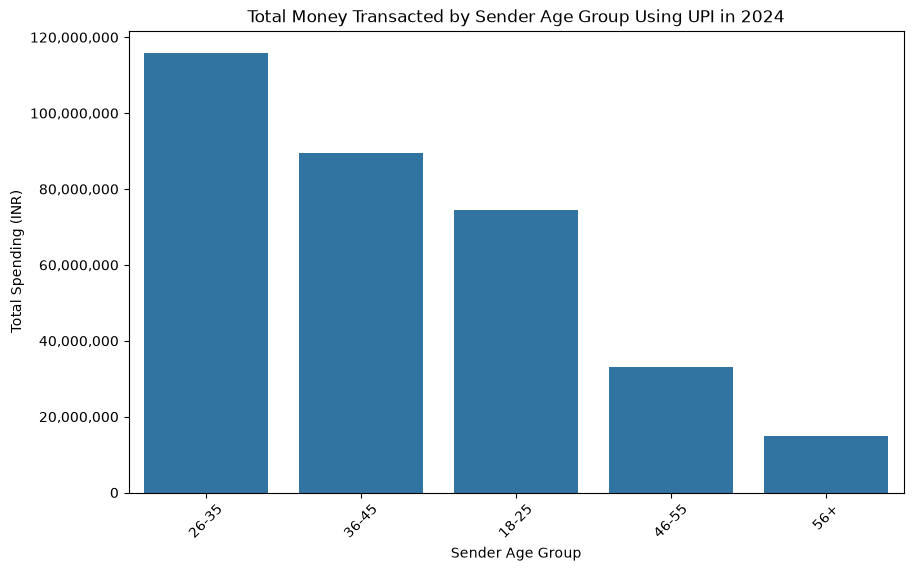

In [7]:
# We first plot a bar chart between different age groups and their spending.
sender_spend = upi_df.groupby('sender_age_group')['amount (INR)'].sum().sort_values(ascending=False)


plt.figure(figsize=(10, 6))
sn.barplot(x=sender_spend.index, y=sender_spend.values)
plt.xlabel("Sender Age Group")
plt.ylabel("Total Spending (INR)")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.title("Total Money Transacted by Sender Age Group Using UPI in 2024")
plt.show()

So from the above Bar Plot it is clear that the Sender Age Group of `26-35` have transacted the most using UPI in 2024, while the Age Group `56+` have done so the least.

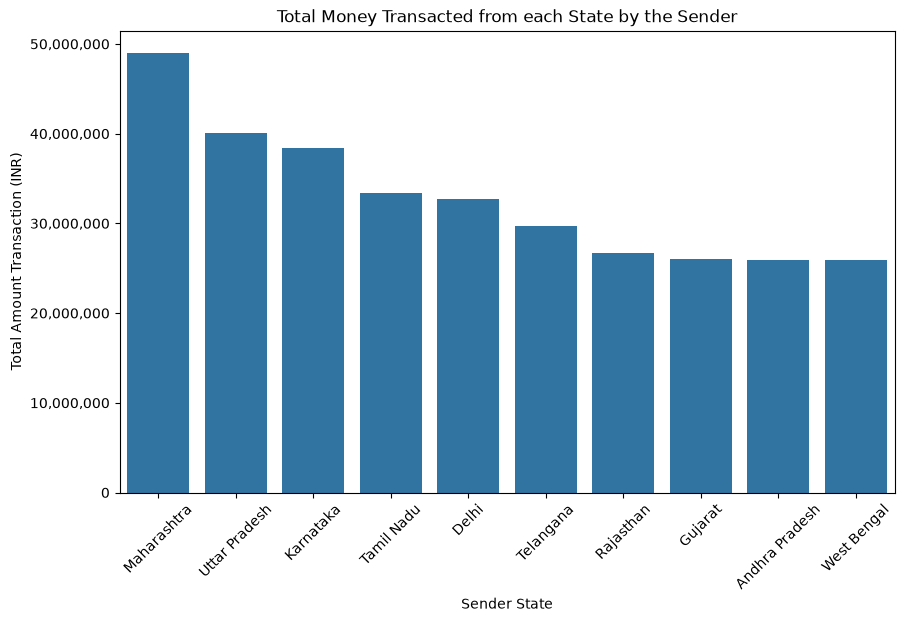

In [8]:
# Now we do a sender state-wise analysis of the expenditure using a bar-chart
sender_spend_statewise = upi_df.groupby('sender_state')['amount (INR)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sn.barplot(x=sender_spend_statewise.index, y=sender_spend_statewise.values)
plt.title("Total Money Transacted from each State by the Sender")
plt.xlabel("Sender State")
plt.ylabel("Total Amount Transaction (INR)")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.xticks(rotation=45)
plt.show()

So here we see that People from the `sender_state` Maharashtra have the highest transaction amount in the year 2024, while West Bengal has the lowest

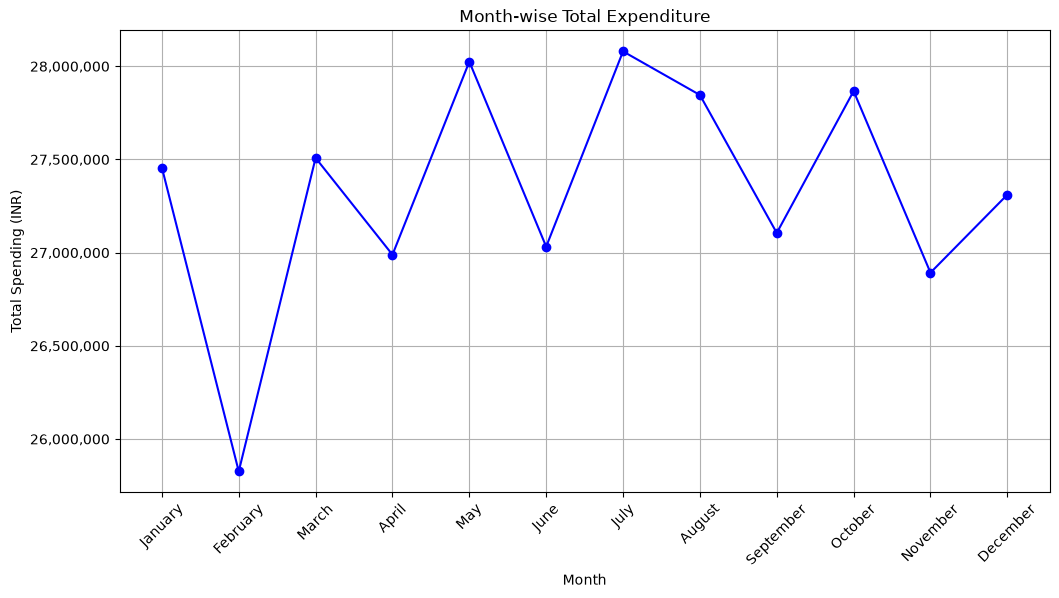

In [9]:
# Next we see the Month-wise Money Transaction trend of 2024.

upi_df['month'] = upi_df['timestamp'].dt.month_name()
upi_df['month_num'] = upi_df['timestamp'].dt.month

monthly_expenditure = upi_df.groupby(['month_num', 'month'])['amount (INR)'].sum().reset_index()
monthly_expenditure = monthly_expenditure.sort_values('month_num')

plt.figure(figsize=(12, 6))
plt.plot(monthly_expenditure['month'], monthly_expenditure['amount (INR)'], marker='o', linestyle='-', color='blue')
plt.title("Month-wise Total Expenditure")
plt.xlabel("Month")
plt.ylabel("Total Spending (INR)")
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.grid()
plt.show()

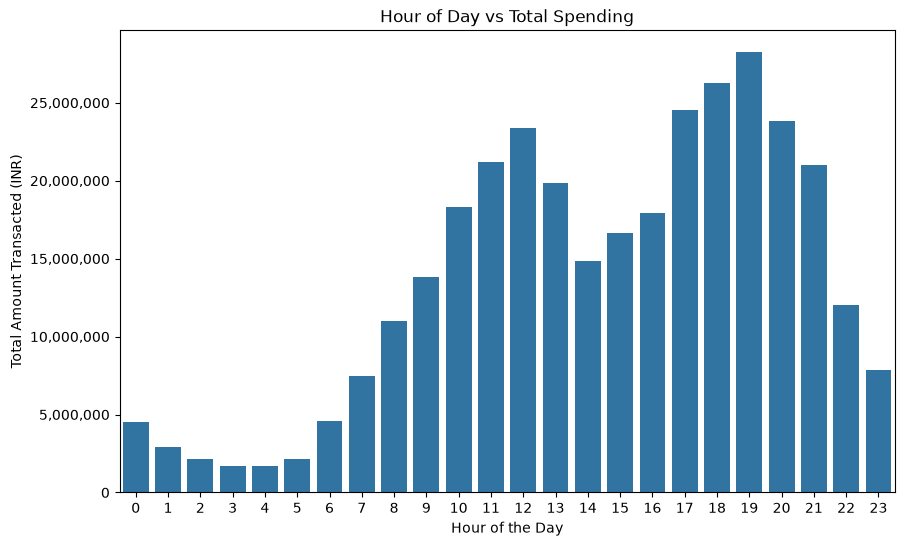

In [10]:
# Now we shall track the Hour of Day vs Total Spending to see which Hour of the day the most and
# least expenditures are done in a day.
hourly_spend = upi_df.groupby('hour_of_day')['amount (INR)'].sum()

plt.figure(figsize=(10, 6))
sn.barplot(x=hourly_spend.index, y=hourly_spend.values)
plt.title("Hour of Day vs Total Spending")
plt.xlabel("Hour of the Day")
plt.ylabel("Total Amount Transacted (INR)")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

So from the bar plot we can see that at the 19th hour of the day (i.e. 7-8 pm) the people have made the most transactions and at the 3rd hour of the day (i.e. 3-4 am) the people have made the least transactions.

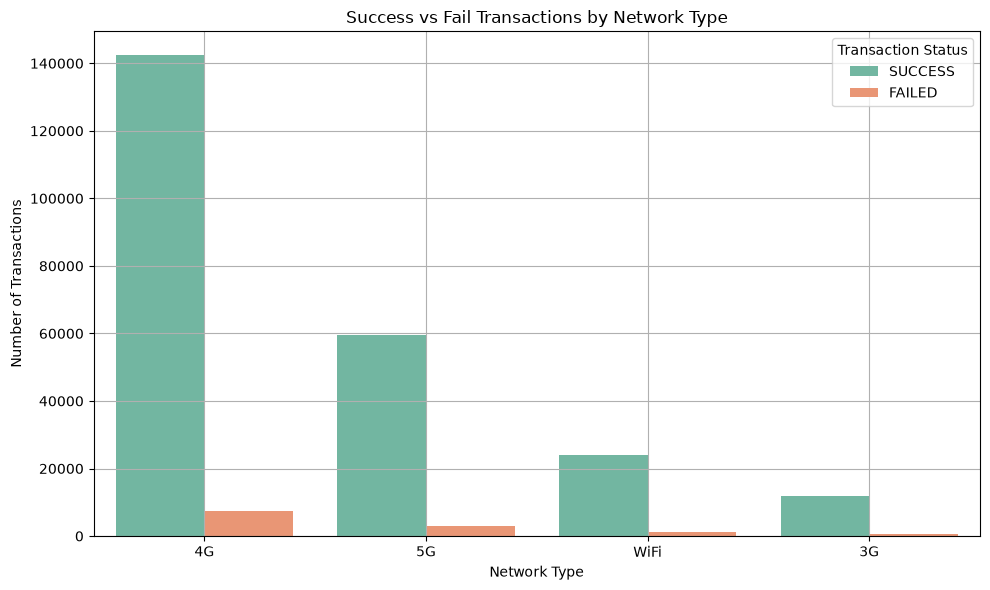

In [11]:
# Now we shall check the Payment Status vs the Type of Network used.
plt.figure(figsize=(10,6))
sn.countplot(data=upi_df, x='network_type', hue='transaction_status', palette='Set2')

plt.title('Success vs Fail Transactions by Network Type')
plt.xlabel('Network Type')
plt.ylabel('Number of Transactions')
plt.legend(title='Transaction Status')
plt.tight_layout()
plt.grid()
plt.show()


So here we see that, most of the transactions made in 2024 have been done using the `Network Type` **4G** while least number of transactions have been done using **3G** `Network Type`.

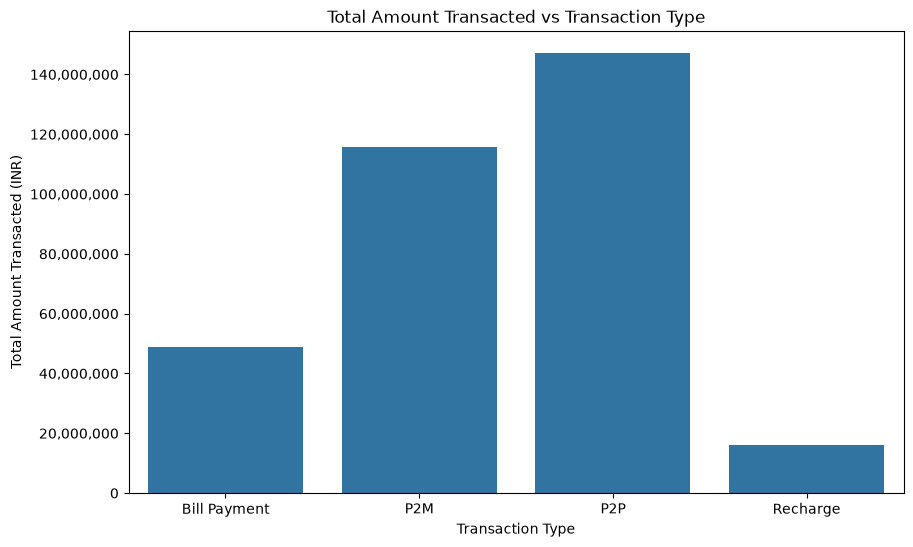

In [12]:
# We plot a bar char to check on which Transaction Type people spend more.
type_spend = upi_df.groupby('transaction type')['amount (INR)'].sum()
plt.figure(figsize=(10, 6))
sn.barplot(x=type_spend.index, y=type_spend.values)
plt.xlabel("Transaction Type")
plt.ylabel("Total Amount Transacted (INR)")
plt.title("Total Amount Transacted vs Transaction Type")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

Here `P2M` is the Transaction Type Peer to Merchant and `P2P` is Peer to Peer.

We observe that the most amount spent is on Peer to Peer type of Transactions and least on Recharge type of Transactions.

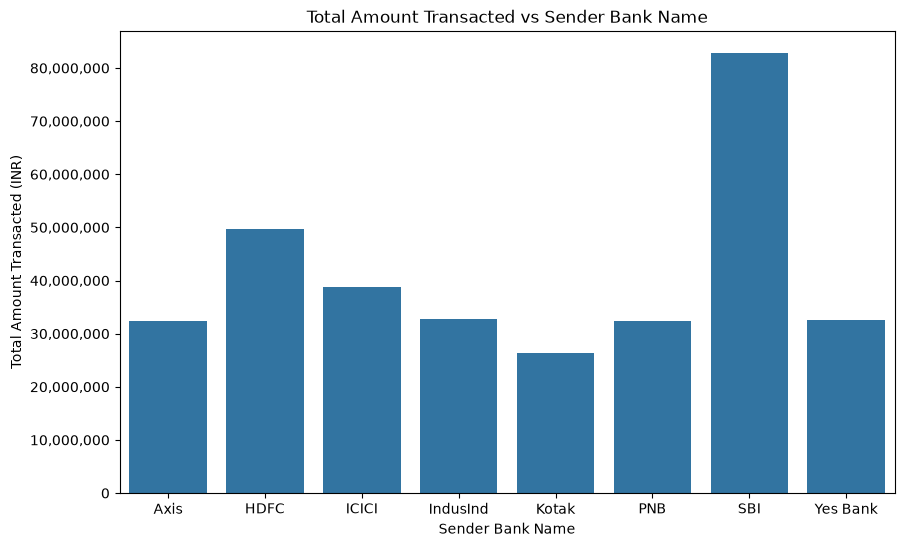

In [13]:
# Bank-wise Transaction Spending.
sender_bank_spend = upi_df.groupby('sender_bank')['amount (INR)'].sum()

plt.figure(figsize=(10, 6))
sn.barplot(x=sender_bank_spend.index, y=sender_bank_spend.values)
plt.xlabel('Sender Bank Name')
plt.ylabel('Total Amount Transacted (INR)')
plt.title("Total Amount Transacted vs Sender Bank Name")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

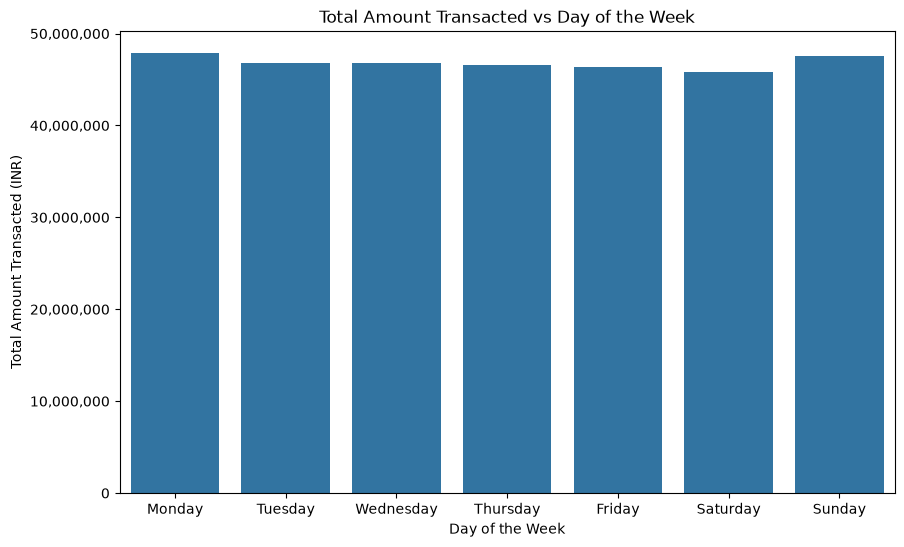

In [14]:
# We check on which Day of the Week most people have transaction made.
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
upi_df['day_of_week'] = pd.Categorical(upi_df['day_of_week'], categories=day_order, ordered=True)

# Group and plot

day_of_week_spend = upi_df.groupby('day_of_week', observed=True)['amount (INR)'].sum()


plt.figure(figsize=(10, 6))
sn.barplot(x=day_of_week_spend.index, y=day_of_week_spend.values)
plt.xlabel('Day of the Week')
plt.ylabel('Total Amount Transacted (INR)')
plt.title("Total Amount Transacted vs Day of the Week")
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

As we can see that every day of the week has nearly the same amount of total money transacted throughout the year.

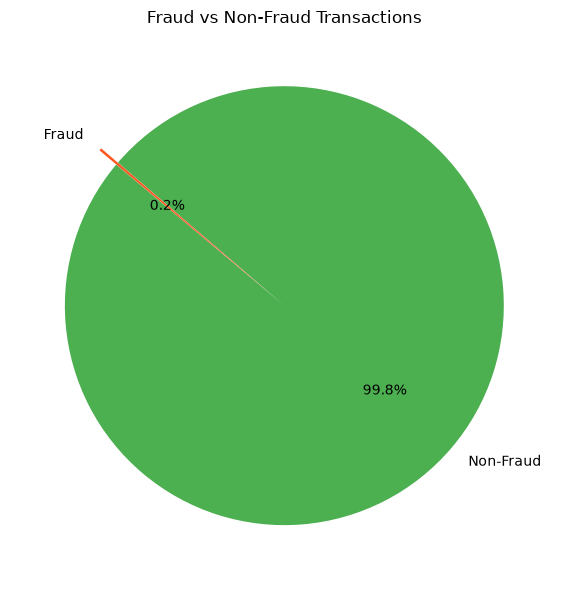

In [15]:
# We now check how many transactions were involved for Fraud vs Non-fraud Transactions
fraud_counts = upi_df['fraud_flag'].value_counts()


labels = ['Non-Fraud', 'Fraud'] if 0 in fraud_counts.index else ['Fraud', 'Non-Fraud']

plt.figure(figsize=(6, 6))
plt.pie(fraud_counts.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=['#4CAF50', '#FF5722'],
        explode=(0, 0.1) if 1 in fraud_counts.index else (0.1, 0))

plt.title('Fraud vs Non-Fraud Transactions')
plt.tight_layout()
plt.show()

We see there are only 0.2% Fraudelent transactions compared to the 99.8% Non-Fraudelent Transactions.

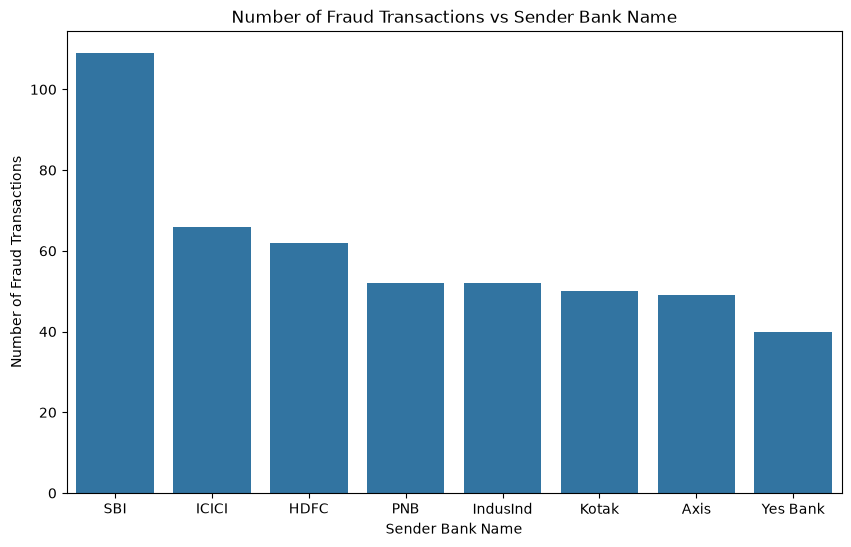

In [16]:
# Checking which Bank has the most Fraudulent Transactions.
fraud_df = upi_df[upi_df['fraud_flag'] == 1]
sender_bank_fraud = fraud_df['sender_bank'].value_counts()

plt.figure(figsize=(10, 6))
sn.barplot(x=sender_bank_fraud.index, y=sender_bank_fraud.values)
plt.xlabel('Sender Bank Name')
plt.ylabel('Number of Fraud Transactions')
plt.title("Number of Fraud Transactions vs Sender Bank Name")
plt.show()

**DATA PRE-PROCESSING FOR MODELING**

First we check for any null or missing values throughout the dataset.

In [17]:
print(upi_df.isnull().sum())

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
month                 0
month_num             0
dtype: int64


We see that there are no null values for either of the columns.

Now we shall encode categorical values.

In [18]:
categorical_features_m1 = ['transaction type', 'merchant_category', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']
new_upi_df = upi_df.drop(['transaction id', 'timestamp'], axis=1)
encoded_df = pd.get_dummies(new_upi_df[categorical_features_m1], drop_first=True)
X_m1 = encoded_df

In [19]:
Y_m1 = new_upi_df['fraud_flag']

In [20]:
X_m2 = list(encoded_df.columns)
Y_m2 = new_upi_df['transaction_status']

**BUILDING CLASSIFICATION MODELS**

**1.To predict for `fraud_flag`**

In [21]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X_m1, Y_m1, test_size=0.3, random_state=42, stratify=Y_m1)

logit = LogisticRegression()
logit.fit(X1_train, y1_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [22]:
y1_pred_logit = logit.predict(X1_test)


In [23]:
from sklearn import metrics
def draw_roc_curve(model, test_X, test_y):
    test_results_df = pd.DataFrame({'actual': test_y})
    test_results_df = test_results_df.reset_index()

    predict_proba_df = pd.DataFrame(model.predict_proba(test_X))
    test_results_df['chd_1'] = predict_proba_df.iloc[:, 1:2]

    fpr, tpr, thresholds = metrics.roc_curve(test_results_df.actual, test_results_df.chd_1, drop_intermediate=False)

    auc_score = metrics.roc_auc_score(test_results_df.actual, test_results_df.chd_1)

    plt.figure(figsize=(8, 6))

    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % auc_score)

    plt.plot([0,1], [0,1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.xlabel('False Positive Rate or [1 - true Negative Rate]')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characterisic Example')
    plt.legend(loc='lower right')
    plt.show()

    return auc_score, fpr, tpr, thresholds

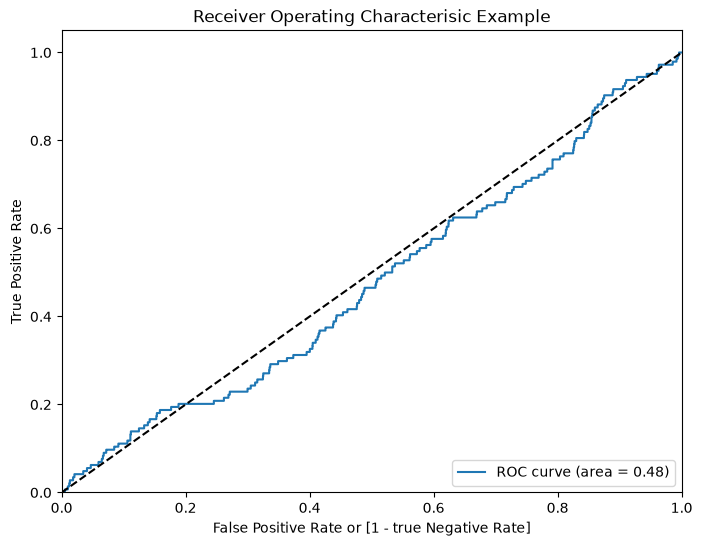

In [24]:
_, _, _, _ = draw_roc_curve(logit, X1_test, y1_test)

In [25]:
radm_clf1 = RandomForestClassifier(max_depth=10, n_estimators=10)
radm_clf1.fit(X1_train, y1_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

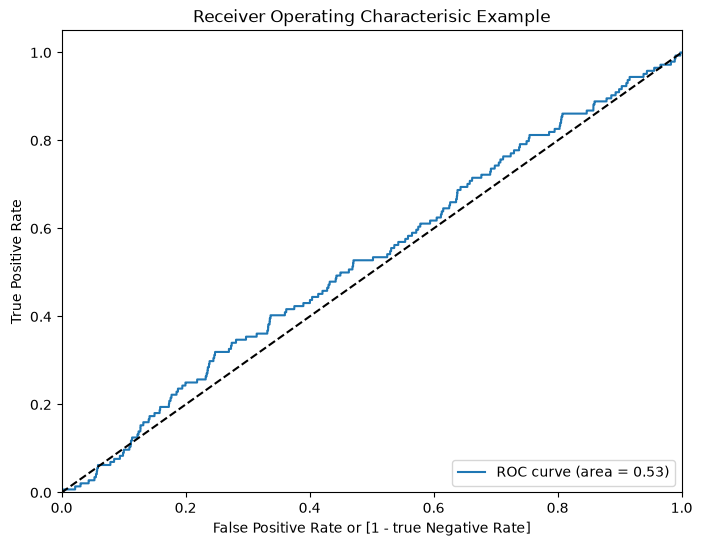

In [26]:
_, _, _, _ = draw_roc_curve(radm_clf1, X1_test, y1_test)

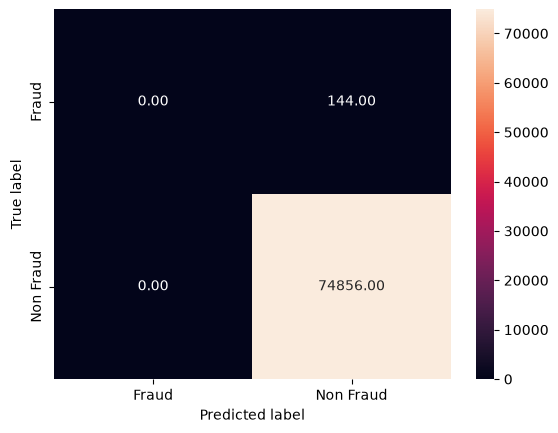

In [27]:
def draw_cm(actual, predicted):
    cm = metrics.confusion_matrix(actual, predicted, labels=[1,0])
    sn.heatmap(cm, annot=True, fmt='.2f', xticklabels = ["Fraud", "Non Fraud"], yticklabels = ["Fraud", "Non Fraud"])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

pred_y1 = radm_clf1.predict(X1_test)
draw_cm(y1_test, pred_y1)

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y1_test, pred_y1, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     74856
           1       0.00      0.00      0.00       144

    accuracy                           1.00     75000
   macro avg       0.50      0.50      0.50     75000
weighted avg       1.00      1.00      1.00     75000



From the above data we see that the ROC AUC score for the Logistic Regression Model and the Random Forest Classifier, is low 0.48 and 0.49 respectively, even if the precision, recall and accuracy is 1.00 and also the Confusion Matrix shows that all the Fradulent Values are being classified as Non-Fraud. This is happening due to the Data Set being highly Imabalanced which we can see below.

In [29]:
upi_df['fraud_flag'].value_counts()

fraud_flag
0    249520
1       480
Name: count, dtype: int64

From the data we see that the number of Fraudulent Transactions is really low. This is casuing the model to mark all Fraudulent Data as Non - Fraudulent. To fix this we resample the data to a fixed number, i.e. we Upsample the Fraudulent Values to a certain number and Downsample the Non-Fraudulent Values to a certain number. We choose 10,000 as this fixed number.

So we shall Upsample the Fraudulent Values to 10,000 and Downsample the Non-Fraudulent Values to 10,000.

**Resampling the Data**

***1. Downsampling the Non-Fradulent Values***

In [30]:
from sklearn.utils import resample, shuffle
non_fraud = upi_df[upi_df['fraud_flag'] == 0]
fraud = upi_df[upi_df['fraud_flag'] == 1]

# Downsampling the Number of Non-Fraudelent Transactions
non_fraud_downsampled = resample(non_fraud, replace=False, n_samples=10000, random_state=42)
combined_df = pd.concat([non_fraud_downsampled, fraud])

combined_df['fraud_flag'].value_counts()

fraud_flag
0    10000
1      480
Name: count, dtype: int64

***2. Upsampling the Fradulent Values***

In [31]:
non_fraud = combined_df[combined_df['fraud_flag'] == 0]
fraud = combined_df[combined_df['fraud_flag'] == 1]

fraud_upsampled = resample(fraud, replace=True, n_samples=10000, random_state=42)
combined_df2 = pd.concat([fraud_upsampled, non_fraud])

combined_df2['fraud_flag'].value_counts()



fraud_flag
1    10000
0    10000
Name: count, dtype: int64

We shuffle the dataset to avoid the model to learn the order of Fraudulent and Non-Fraudulent values.

In [32]:
shuffled_df = shuffle(combined_df2, random_state=42)

In [33]:
categorical_features = ['transaction type', 'merchant_category', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'day_of_week']
new_upi_df = shuffled_df.drop(['transaction id', 'timestamp'], axis=1)
encoded_df = pd.get_dummies(new_upi_df[categorical_features], drop_first=True)
X = encoded_df

In [34]:
Y_1 = shuffled_df['fraud_flag']

In [35]:
train_X1, test_X1, train_y1, test_y1 = train_test_split(X, Y_1, test_size=0.3, random_state=42)

In [36]:
radm_clf = RandomForestClassifier(max_depth=10, n_estimators=100, class_weight="balanced")
radm_clf.fit(train_X1, train_y1)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fash

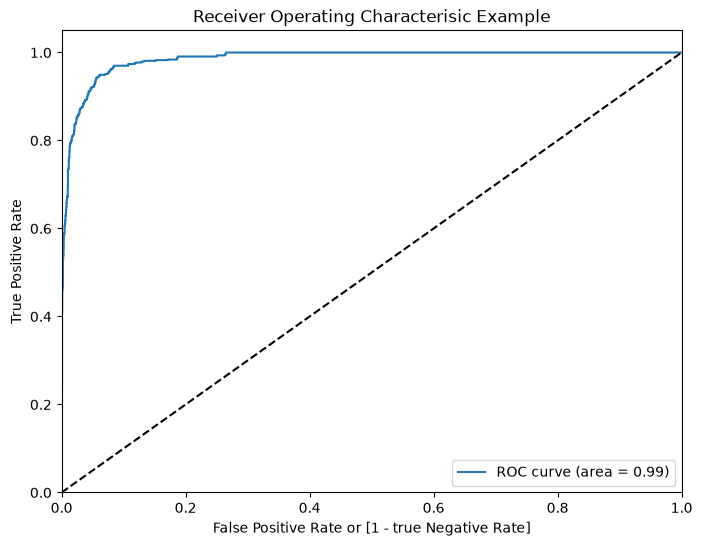

In [37]:
_, _, _, _ = draw_roc_curve(radm_clf, test_X1, test_y1)

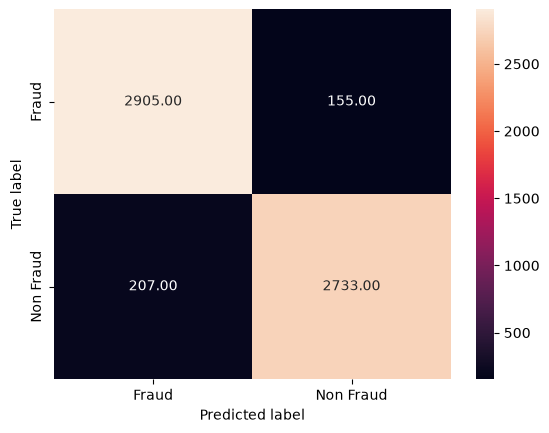

In [38]:
pred_y = radm_clf.predict(test_X1)
cm = draw_cm(test_y1, pred_y)

In [39]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(radm_clf, X, Y_1, cv=10, scoring='roc_auc')
print("CV ROC AUC scores:", scores)
print("Mean ROC AUC:", scores.mean())


CV ROC AUC scores: [0.987496 0.992414 0.985792 0.988813 0.988961 0.991422 0.986833 0.99012
 0.989035 0.987218]
Mean ROC AUC: 0.9888104


In [40]:
print(classification_report(test_y1, pred_y))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94      2940
           1       0.93      0.95      0.94      3060

    accuracy                           0.94      6000
   macro avg       0.94      0.94      0.94      6000
weighted avg       0.94      0.94      0.94      6000



So we see that, after resampling and shuffling the data the Random Forest gives a ROC AUC score as 0.99 with a really good classification report as show above. We can consider the model `radm_clf` is consistently accurate.

Now we shall check out the top features.

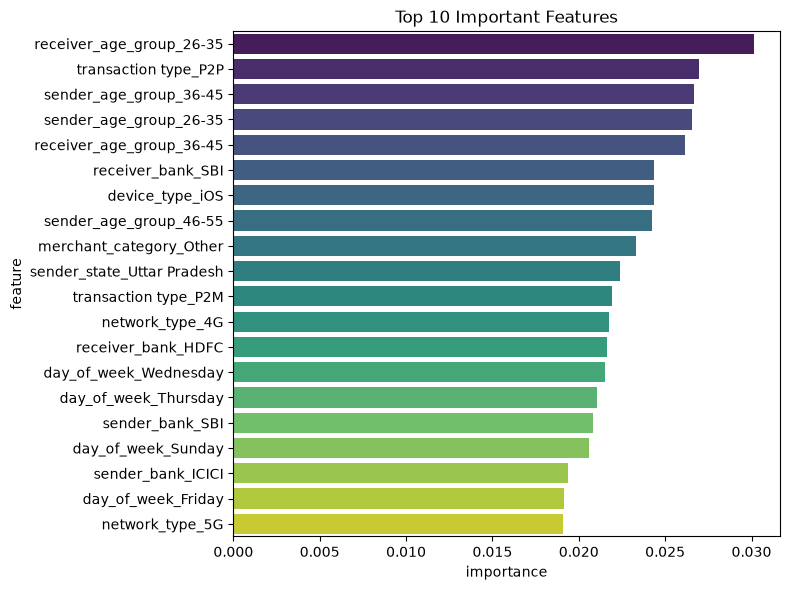

In [41]:
feature_rank = pd.DataFrame({'feature': train_X1.columns, 'importance': radm_clf.feature_importances_})

feature_rank = feature_rank.sort_values('importance', ascending=False)
top_features = feature_rank.head(20)

plt.figure(figsize=(8, 6))
sn.barplot(y='feature', x='importance', data=top_features, palette='viridis', hue='feature', dodge=False, legend=False)
plt.title('Top 10 Important Features')
plt.tight_layout()
plt.show()

So the above features give us the top 20 feautres which are really important to classify between Fraudulent Transactions and Non-Fraudulent Transactions.

## **Conclusion**

In this project, we developed a machine learning model to detect **fraudulent UPI transactions** using real-world-like transaction data. One of the primary challenges encountered was the **extremely imbalanced dataset**, where fraudulent transactions were vastly outnumbered by legitimate ones, leading to poor initial model performance.

To address this, **resampling techniques** were used to balance the dataset, which drastically improved model outcomes.

### Key Feature Insights:
Based on the feature importance from the Random Forest model (as seen in the plot above), the most influential features for predicting fraud were:

- **Receiver Age Group: 26–35**
- **Receiver Bank: SBI**
- **Transaction Type: P2M & P2P**
- **Device Type: iOS**
- **Sender Age Groups: 26–55**
- **Merchant Category: Other**
- **Day of Week: Wednesday**

These features reveal behavioral and demographic patterns that are closely associated with fraudulent activity in UPI transactions.

### Final Model Performance (Random Forest on Resampled Data):

| Metric         | Score     |
|----------------|-----------|
| **ROC AUC**    | **0.9888** |
| **Precision**  | High (very few false positives) |
| **Recall**     | High (fraudulent transactions correctly captured) |
| **Accuracy**   | Very High (on both train/test with cross-validation) |

The **ROC AUC score of ~0.99** shows that the model can effectively distinguish between fraud and non-fraud transactions. This confirms the value of **resampling** and using ensemble models for handling imbalanced classification problems.

---

With strong **feature insights**, **high evaluation scores**, and thorough **exploration of imbalanced learning**, this project successfully meets its goal of building an effective fraud detection system.
